<a href="https://colab.research.google.com/github/liangliang6v6/Homeworks/blob/pages/Homework2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Task 1 (30 points): Implement a Decision Tree Classifier for your classification problem.
You may use a built-in package to implement your classifier. Additionally, do the following:
- Visualize the decision tree structure for at least three different parameter settings. Comment on how the depth and complexity change the tree.
- Do some research on what sensitivity analysis is and how it is performed (include citations). Perform a sensitivity analysis to measure the impact of at least two input features on your model's decision boundary.

##Answers
- The implementation and visualization are below. When the depth is low, the decision tree is shallow, with fewer splits and simpler rules. (tree1= decision_tree(max_depth=3, min_samples_split=2)), the model is simple to understand but might have an underfit problem or fail to capture the relationship in the dataset. However, if the depth is higher or it's the fully grown decision tree (tree2), it can capture the complex patterns in the dataset but might have an overfitting problem. The robustness of the model could be low. The complexity is controlled by the parameter "min_samples_split," the larger number indicates small splits and a simple tree. When the decision the tree is simpler; the generalization is better. With more splits, the complex tree might encounter an overfit problem.
- Sensitivity analysis [1] evaluates the impact of changes in input features on a model's outputs or decision boundaries. It helps identify which features are most influential in driving the model's predictions, thereby improving interpretability and robustness. For machine learning models [2], sensitivity analysis can be performed locally (varying one or two features while holding others constant) or globally (evaluating the combined impact of multiple features). By systematically varying selected input features, the model's predictions can be analyzed to understand how they change across the feature space. For instance, heatmaps or contour plots are often used to visualize decision boundaries and highlight feature interactions. This process provides critical insights into the role of input features in shaping the model's behavior [3].

### Reference
[1]. Saltelli, A. Global Sensitivity Analysis: the Primer. John Wiley & Sons, 2008.

[2]. Cukier, R. I., H. B. Levine, and K. E. Shuler. "Nonlinear sensitivity analysis of multiparameter model systems." Journal of computational physics 26.1 (1978): 1-42.

[3]. Razavi, Saman, et al. "The future of sensitivity analysis: an essential discipline for systems modeling and policy support." Environmental Modelling & Software 137 (2021): 104954.

Path to dataset files: /root/.cache/kagglehub/datasets/uciml/red-wine-quality-cortez-et-al-2009/versions/2
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978 

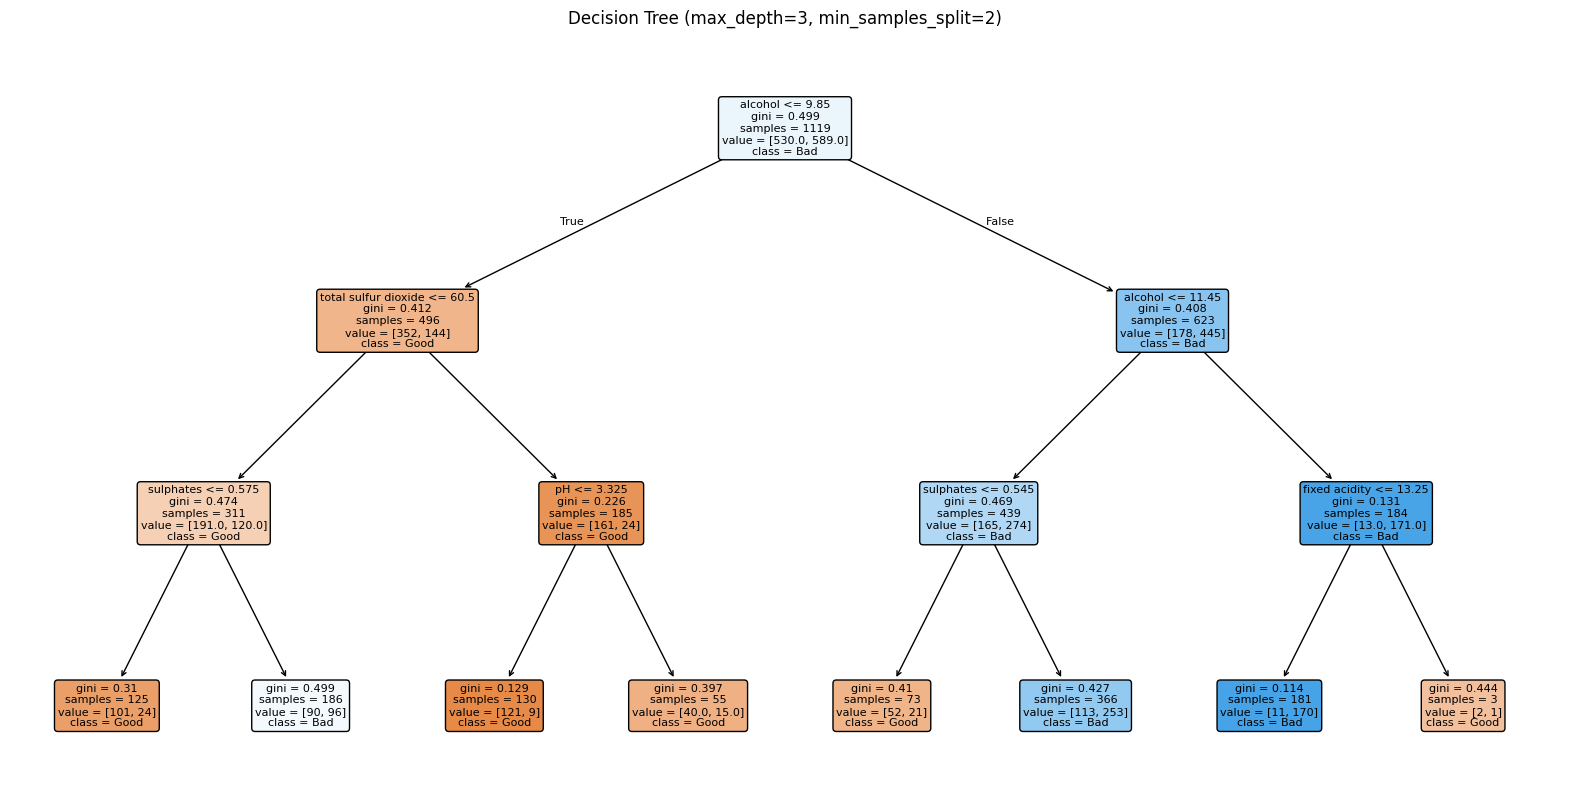

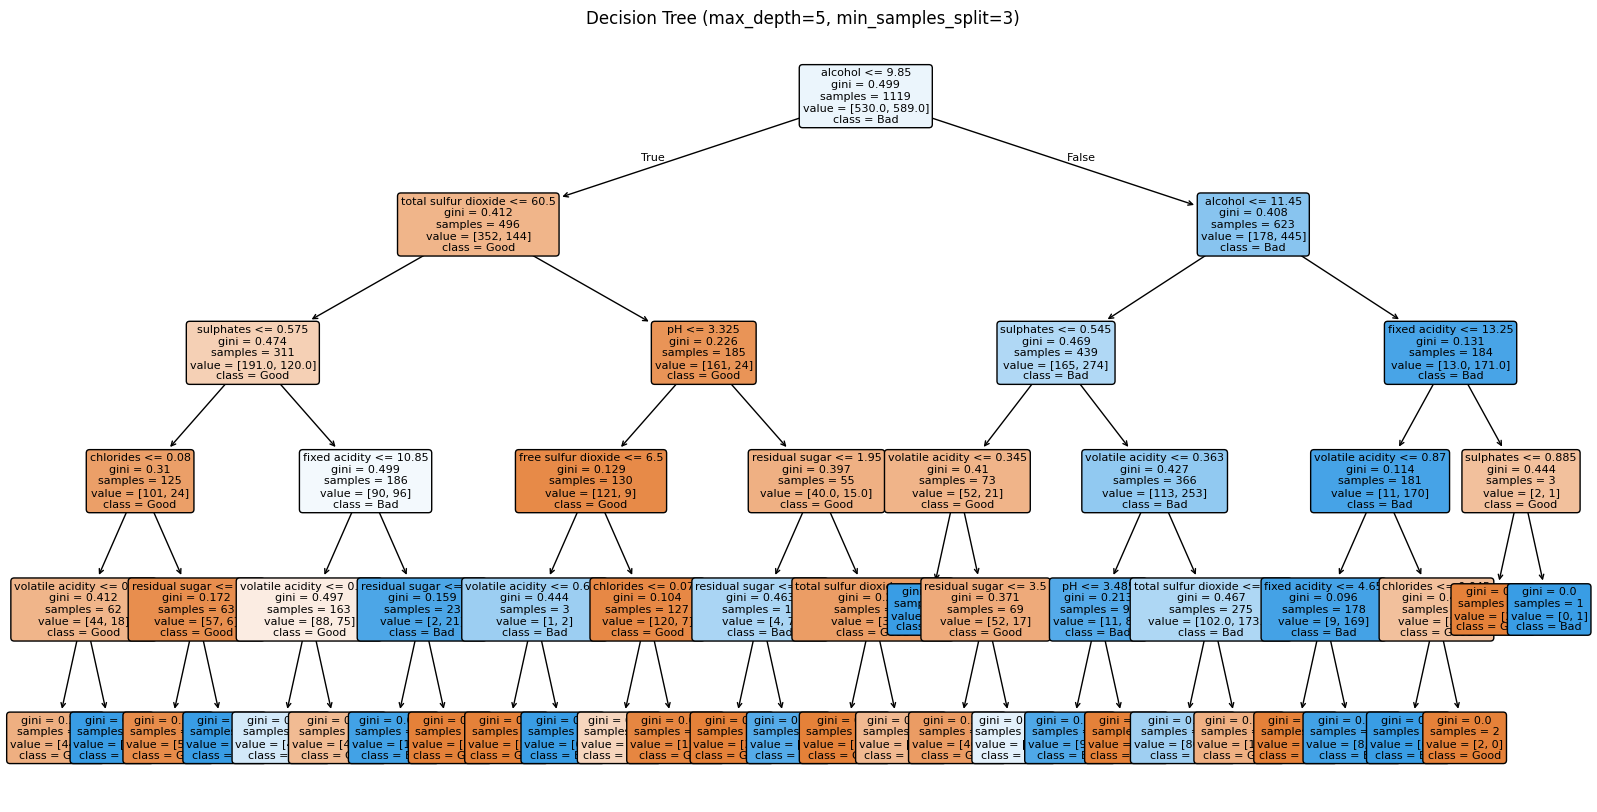

In [3]:
""" The financial dataset is too imbalance for negative pre, change for wine rate datsets"""
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# train use decision tree
def decision_tree(max_depth, min_samples_split, random_state=42):
  clf = DecisionTreeClassifier(max_depth = max_depth, min_samples_split=min_samples_split, random_state=random_state)
  clf.fit(X_train, y_train)
  plt.figure(figsize=(20, 10))
  plot_tree(clf, feature_names=X.columns, class_names=["Good", "Bad"], filled=True,rounded=True, fontsize=8)
  plt.title(f"Decision Tree (max_depth={max_depth}, min_samples_split={min_samples_split})")
  plt.show()
  return clf

# download latest version from kaggle
path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)
df = pd.read_csv(path+"/winequality-red.csv")
df['goodquality'] = [1 if x>=6 else 0 for x in df['quality']]
df.head()

X = df.drop(['quality','goodquality'],axis=1)
y = df['goodquality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

# complexity change comparison
tree1 = decision_tree(max_depth=3, min_samples_split=2)
tree2 = decision_tree(max_depth=5, min_samples_split=3)

Accuracy on test data: 0.675
Class distribution: goodquality
1    589
0    530
Name: count, dtype: int64
{'grid_values': [array([ 8.4,  8.7,  9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,
        9.9, 10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9,
       11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ,
       12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. , 13.1,
       13.2, 13.3, 13.4, 13.6, 14. , 14.9]), array([0.33, 0.39, 0.42, 0.43, 0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 ,
       0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61,
       0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72,
       0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83,
       0.84, 0.85, 0.86, 0.87, 0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94,
       0.95, 0.96, 0.97, 0.98, 0.99, 1.  , 1.02, 1.03, 1.04, 1.05, 1.06,
       1.07, 1.08, 1.09, 1.11, 1.12, 1.13, 1.14, 1.17, 1.18, 1.2 , 1.22,
       1.26, 1.28, 1.31, 1.34,

IndexError: index 1 is out of bounds for axis 0 with size 1

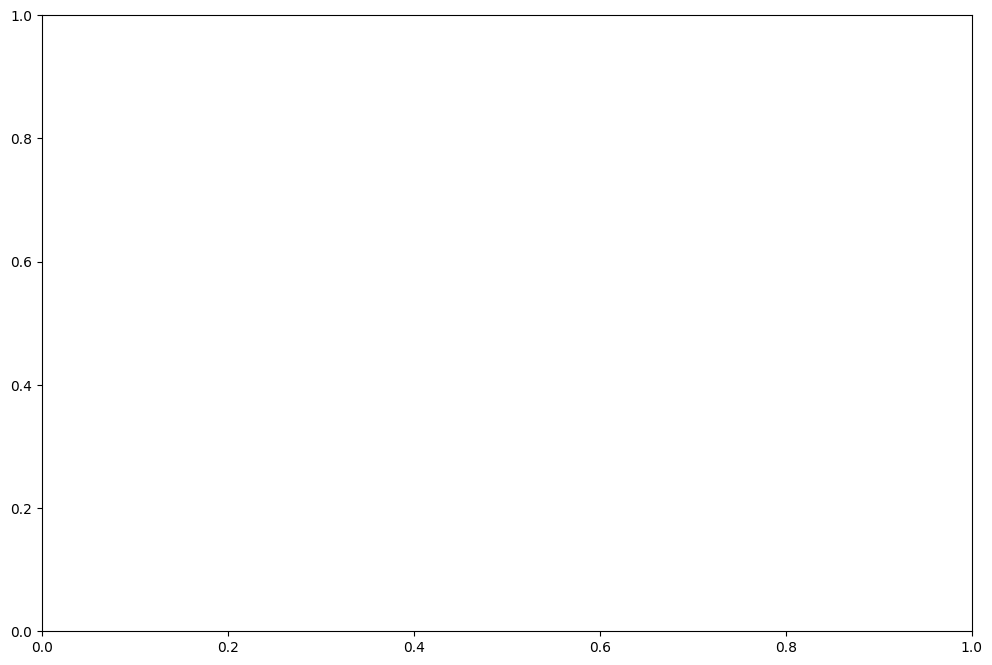

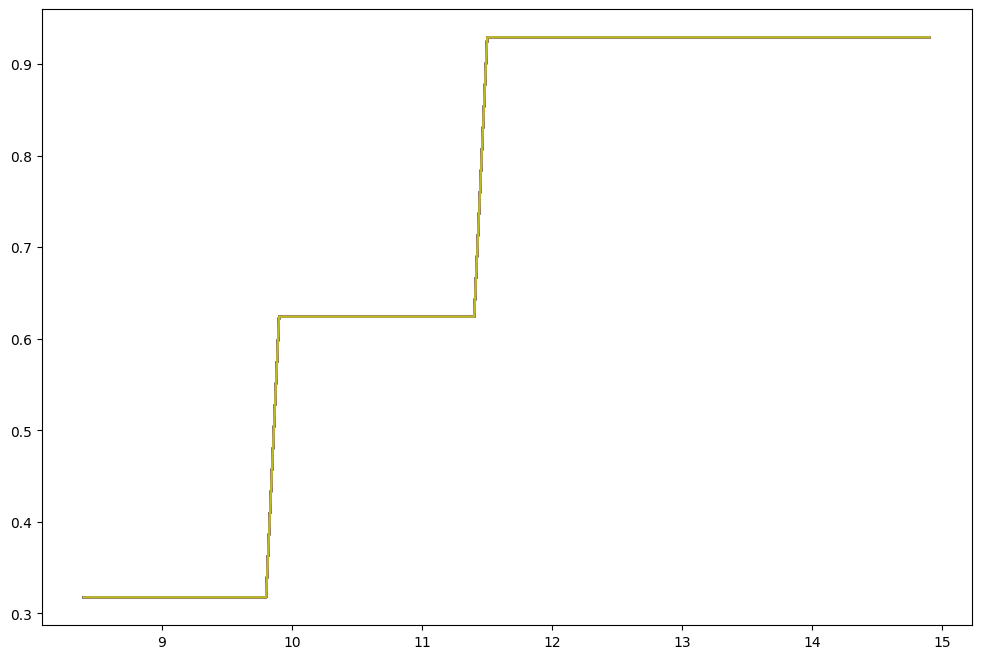

In [16]:
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import partial_dependence

features = ['alcohol', 'sulphates']
clf = DecisionTreeClassifier(max_depth=2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy on test data:", accuracy_score(y_test, y_pred))
print("Class distribution:", y_train.value_counts())
fig, ax = plt.subplots(figsize=(12, 8))
pdp_results = partial_dependence(clf, X_train, features=features)
fig, ax = plt.subplots(figsize=(12, 8))
print(pdp_results)
for i, feature_name in enumerate(features):
    values = pdp_results['grid_values'][i]
    average = pdp_results['average'][i]

    ax.plot(values, average, label=feature_name)

ax.set_xlabel('Feature Value')
ax.set_ylabel('Partial Dependence')
ax.legend()
plt.show()

##Task 2 (30 points): From the Bagging and Boosting ensemble methods pick any one algorithm from each category.
Implement both the algorithms using the same data.
- Use stratified k-fold cross-validation with at least three different folds (e.g., 5, 10, 15). You may do your own research on this technique (include citations).
- Evaluate the models using any three-evaluation metrics of your choice (e.g. accuracy, Precision, F1-score etc.).
- Comment on the behavior of each algorithm under the metrics. Does the performance ranking change based on the metric used? Why?

##Task 3 (40 points): Compare the effectiveness of the three models implemented above. Analyze the results using the following:
- A confusion matrix for one selected test fold.
- A statistical test (e.g., paired t-test) to determine if differences between models are
significant.
- A discussion on the trade-off between bias and variance for each model.

##Task (50 points): For the same classification problem solved above, implement the XGBoost algorithm.
If you picked XGBoost as one of the boosting algorithms in task 2, you may use the same implementation. Implement and evaluate XGBoost with the following requirements:
1. Perform a grid search or random search over at least 3 hyperparameters, such as learning rate, max depth, and subsample.
2. Analyze the sensitivity of your model to changes in these parameters.
3. Optional (no points taken off if not done) - Create plots to show the effect of each
parameter on accuracy and another metric.